## TF-IDF(Axis 1) + MLP(Axis 2)

In [2]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from pubmed_loader import PubMedQAData
from preprocessing import preprocess_tfidf
from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, training_curves

In [3]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

In [4]:
def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

In [5]:
set_all_seeds()

All seeds set to 11


### 1. Data Loading & Preprocessing

In [6]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set,   use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set,  use_mesh=True)

print(f"train: {len(train_texts)} samples")
print(f"dev:   {len(dev_texts)}   samples")
print(f"test:  {len(test_texts)}  samples")

train: 450 samples
dev:   50   samples
test:  500  samples


In [7]:
print("Train:", np.bincount(train_labels))
print("Dev:  ", np.bincount(dev_labels))
print("Test: ", np.bincount(test_labels))

Train: [249 152  49]
Dev:   [27 17  6]
Test:  [276 169  55]


In [8]:
combined_texts = train_texts + dev_texts
combined_labels = train_labels + dev_labels

### 2. TF-IDF Vectorisation

In [9]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

In [10]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=med_stopwords,
    token_pattern=r"\b[a-zA-Z\-]\w*\b",
    max_features=5000,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)
X_test  = vectorizer.transform(test_texts)

INPUT_DIM = X_train.shape[1]
print(f"TF-IDF input dim: {INPUT_DIM}")

TF-IDF input dim: 5000


### 3. MLP

Wrap datases in DataLoader objects

In [11]:
def convert_to_tensor(X_sparse, labels):
    # Convert sparse matrix & label list to TensorDataset
    X = torch.tensor(X_sparse.toarray(), dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.long)
    return TensorDataset(X, y)

In [12]:
BATCH_SIZE = 64

train_dataset = convert_to_tensor(X_train, train_labels)
dev_dataset = convert_to_tensor(X_dev,   dev_labels)
test_dataset = convert_to_tensor(X_test,  test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset,   batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

MLP Architecture

In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )
    
    def forward(self, x):
        return self.network(x)

Training

In [14]:
# Training Loop
def train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate, class_weights=None):
    # If weights is not None, apply them to the loss function
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(next(model.parameters()).device))
        print(f"Using Weighted CrossEntropy: {class_weights}")
    else:
        loss_fn = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses = []
    all_dev_losses = []

    # Track the best model
    best_dev_loss = float('inf')
    best_state = None

    for e in range(num_epochs):
        total_correct = 0
        total_trained = 0
        train_losses = []

        model.train()

        for batch_X, batch_y in train_loader:
            # Reset the optimizer
            optimizer.zero_grad()

            # Use the model to perform forward inference on the input data.
            # This will run the forward() function.
            output = model(batch_X)

            # Compute the loss for the current batch of data
            batch_loss = loss_fn(output, batch_y)

            # Perform back propagation to compute the gradients with respect to each weight
            batch_loss.backward()

            # Update the weights using the compute gradients
            optimizer.step()

            # Record the loss from this sample to keep track of progress.
            train_losses.append(batch_loss.item())

            # Count correct labels so we can compute accuracy on the training set
            predicted_labels = output.argmax(1)
            total_correct += (predicted_labels == batch_y).sum().item()
            total_trained += batch_y.size(0)

        train_accuracy = total_correct/total_trained*100
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Training Loss: {:.4f}".format(np.mean(train_losses)),
              "Training Accuracy: {:.4f}%".format(train_accuracy))
        
        all_train_losses.append(np.mean(train_losses))

        # Switch model to evaluation mode
        model.eval()
        total_correct = 0
        total_trained = 0
        dev_losses = []

        with torch.no_grad():
            for dev_input_ids, dev_labels in dev_loader:
                dev_output = model(dev_input_ids)
                
                dev_loss = loss_fn(dev_output, dev_labels)

                dev_losses.append(dev_loss.item())
                
                predicted_labels = dev_output.argmax(1)
                total_correct += (predicted_labels == dev_labels).sum().item()
                total_trained += dev_labels.size(0)
        
        dev_accuracy = total_correct/total_trained*100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(np.mean(dev_losses))
        
        print("Epoch: {}/{}".format((e+1), num_epochs),
              "Validation Loss: {:.4f}".format(np.mean(dev_losses)),
              "Validation Accuracy: {:.4f}%".format(dev_accuracy))

        # Save the best model & Early Stopping
        if mean_dev_loss < best_dev_loss:
            best_dev_loss = mean_dev_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"Best model saved (validation_loss={best_dev_loss:.4f})")

    # Restore the optimal weight and then return
    model.load_state_dict(best_state)
    print(f"Restored best model (validation_loss={best_dev_loss:.4f})")
    
    return model, all_train_losses, all_dev_losses

In [ ]:
set_all_seeds()

num_epochs = 15
learning_rate = 0.001

model = MLP(input_dim=INPUT_DIM)
trained_model, train_losses, dev_losses = train_MLP(num_epochs, model, train_loader, dev_loader, learning_rate)


All seeds set to 11
Epoch: 1/50 Training Loss: 1.0614 Training Accuracy: 55.3333%
Epoch: 1/50 Validation Loss: 1.0473 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0473)
Epoch: 2/50 Training Loss: 1.0201 Training Accuracy: 55.3333%
Epoch: 2/50 Validation Loss: 1.0096 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.0096)
Epoch: 3/50 Training Loss: 0.9597 Training Accuracy: 55.3333%
Epoch: 3/50 Validation Loss: 0.9658 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9658)
Epoch: 4/50 Training Loss: 0.9427 Training Accuracy: 55.3333%
Epoch: 4/50 Validation Loss: 0.9555 Validation Accuracy: 54.0000%
Best model saved (validation_loss=0.9555)
Epoch: 5/50 Training Loss: 0.9192 Training Accuracy: 55.3333%
Epoch: 5/50 Validation Loss: 0.9661 Validation Accuracy: 54.0000%
Epoch: 6/50 Training Loss: 0.7775 Training Accuracy: 55.3333%
Epoch: 6/50 Validation Loss: 0.9636 Validation Accuracy: 54.0000%
Epoch: 7/50 Training Loss: 0.7003 Training A

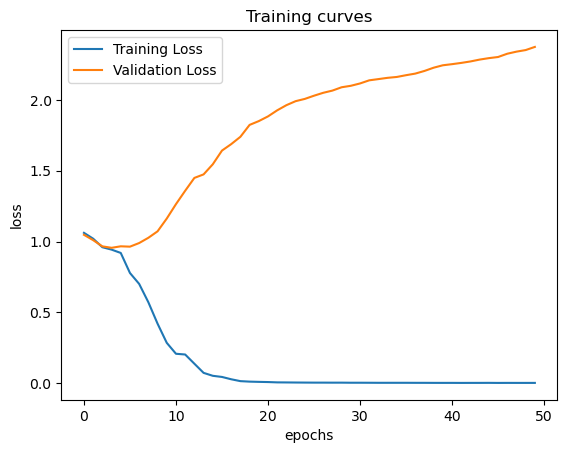

In [17]:
training_curves(train_losses, dev_losses)

### 3. Evaluation

Predict

In [19]:
def predict(model, test_loader):
    model.eval()
    gold_labs = []  # gold labels to return
    pred_labs = []  # predicted labels to return

    with torch.no_grad():
        for inputs, labels in test_loader:
            output = model(inputs)
            predicted_labels = output.argmax(1)
            
            gold_labs.extend(labels.tolist())
            pred_labs.extend(predicted_labels.tolist())

    return gold_labs, pred_labs

In [20]:
y_true, y_pred = predict(trained_model, test_loader)

evaluate(y_pred, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


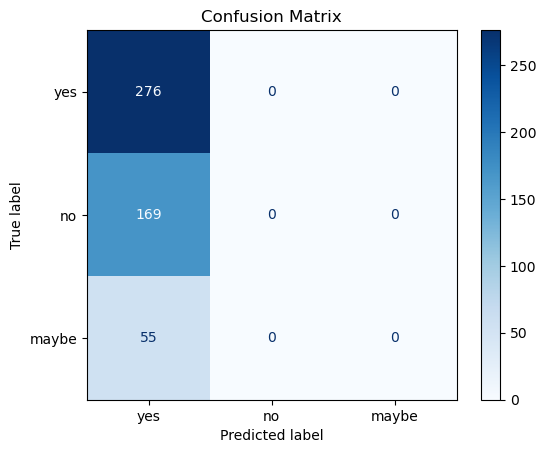

In [21]:
plot_confusion_matrix(y_true, y_pred)

In [22]:
counts = np.bincount(train_labels)
counts_tensor = torch.FloatTensor(counts)
weights = 1.0 / counts_tensor
weights = weights / weights.sum() * 3 # normalization

print(f"counts: {counts} \nWeights: {weights}")

counts: [249 152  49] 
Weights: tensor([0.3886, 0.6366, 1.9748])


In [23]:
set_all_seeds()
model = MLP(input_dim=INPUT_DIM)
trained_model_balanced, train_losses, dev_losses = train_MLP(num_epochs, 
                                                    model, 
                                                    train_loader,
                                                    dev_loader, 
                                                    learning_rate,
                                                    weights)


All seeds set to 11
Using Weighted CrossEntropy: tensor([0.3886, 0.6366, 1.9748])
Epoch: 1/15 Training Loss: 1.1006 Training Accuracy: 55.3333%
Epoch: 1/15 Validation Loss: 1.1024 Validation Accuracy: 54.0000%
Best model saved (validation_loss=1.1024)
Epoch: 2/15 Training Loss: 1.0895 Training Accuracy: 55.3333%
Epoch: 2/15 Validation Loss: 1.1025 Validation Accuracy: 54.0000%
Epoch: 3/15 Training Loss: 1.0716 Training Accuracy: 55.5556%
Epoch: 3/15 Validation Loss: 1.1033 Validation Accuracy: 54.0000%
Epoch: 4/15 Training Loss: 1.0489 Training Accuracy: 67.3333%
Epoch: 4/15 Validation Loss: 1.1030 Validation Accuracy: 54.0000%
Epoch: 5/15 Training Loss: 0.9679 Training Accuracy: 93.1111%
Epoch: 5/15 Validation Loss: 1.1039 Validation Accuracy: 52.0000%
Epoch: 6/15 Training Loss: 0.8333 Training Accuracy: 98.0000%
Epoch: 6/15 Validation Loss: 1.1136 Validation Accuracy: 46.0000%
Epoch: 7/15 Training Loss: 0.6712 Training Accuracy: 99.3333%
Epoch: 7/15 Validation Loss: 1.1467 Validation

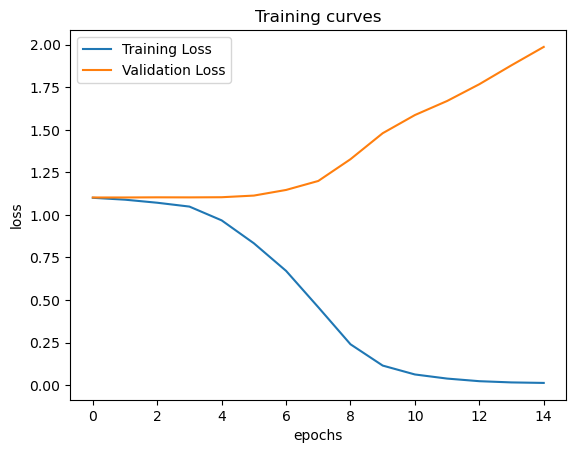

In [24]:
training_curves(train_losses, dev_losses)

In [25]:
y_true, y_pred_balanced = predict(trained_model_balanced, test_loader)

evaluate(y_pred_balanced, y_true, "Test_set")


── Test_set ──
Accuracy: 0.5520  Macro-F1: 0.2371
              precision    recall  f1-score   support

         yes       0.55      1.00      0.71       276
          no       0.00      0.00      0.00       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.55       500
   macro avg       0.18      0.33      0.24       500
weighted avg       0.30      0.55      0.39       500



e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


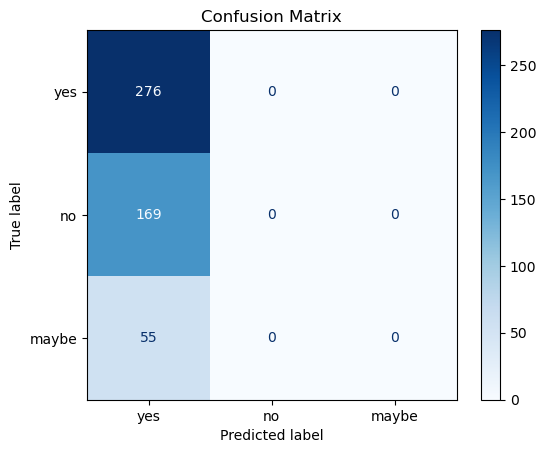

In [26]:
plot_confusion_matrix(y_true, y_pred_balanced)